In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [87]:
df_min_p = pd.read_json("../simulate_sampling_results/pixtral-coco-min_p.jsonl", lines=True, orient="records")
df_min_p["sampling_method"] = df_min_p.apply(lambda x: "min_p", axis=1)

df_top_p = pd.read_json("../simulate_sampling_results/pixtral-coco-top_p.jsonl", lines=True, orient="records")
df_top_p["sampling_method"] = df_top_p.apply(lambda x: "top_p", axis=1)

df = pd.concat([df_min_p, df_top_p])
df["block_idx"] = df.apply(lambda x: x['trial_idx'] // 4, axis=1)

In [38]:
df.columns

Index(['speaker_model', 'listener_model', 'speaker_sampling_method', 'gameid',
       'trial_idx', 'target', 'sampled_descriptions',
       'sampled_descriptions_interpretations',
       'sampled_descriptions_interpretations_no_context',
       'selected_description', 'tiled_description_interpretations',
       'ablated_descriptions', 'ablated_descriptions_interpretations',
       'ablated_descriptions_interpretations_no_context', 'sampling_method',
       'block_idx'],
      dtype='object')

In [39]:
def dictionary_softmax(d):
    denom = sum(np.exp(v) for v in d.values())
    return {k: np.exp(v) / denom for k, v in d.items()}

def mix_logits(d1, d2, alpha=0):
    return {k: (1 + alpha) * d1[k] - alpha * d2[k] for k in d1.keys()}

In [88]:
df = df.explode(
    [
        "sampled_descriptions",
        "sampled_descriptions_interpretations",
        "sampled_descriptions_interpretations_no_context",
        "ablated_descriptions",
        "ablated_descriptions_interpretations",
        "ablated_descriptions_interpretations_no_context",
    ]
)

In [89]:
df["sampled_descriptions_len"] = df.apply(lambda x: len(x["sampled_descriptions"].split()), axis=1)
df["ablated_descriptions_len"] = df.apply(lambda x: len(x["ablated_descriptions"].split()), axis=1)

In [90]:
df["sampled_descriptions_target_prob"] = df.apply(lambda x: dictionary_softmax(x["sampled_descriptions_interpretations"])[x['target']], axis=1)
df["sampled_descriptions_correct"] = df.apply(lambda x: max(x["sampled_descriptions_interpretations"], key=x["sampled_descriptions_interpretations"].get) == x['target'], axis=1)
df["sampled_descriptions_no_context_target_prob"] = df.apply(lambda x: dictionary_softmax(x["sampled_descriptions_interpretations_no_context"])[x['target']], axis=1)
df["sampled_descriptions_no_context_correct"] = df.apply(lambda x: max(x["sampled_descriptions_interpretations_no_context"], key=x["sampled_descriptions_interpretations_no_context"].get) == x['target'], axis=1)

In [91]:
df["ablated_descriptions_target_prob"] = df.apply(lambda x: dictionary_softmax(x["ablated_descriptions_interpretations"])[x['target']], axis=1)
df["ablated_descriptions_correct"] = df.apply(lambda x: max(x["ablated_descriptions_interpretations"], key=x["ablated_descriptions_interpretations"].get) == x['target'], axis=1)
df["ablated_descriptions_no_context_target_prob"] = df.apply(lambda x: dictionary_softmax(x["ablated_descriptions_interpretations_no_context"])[x['target']], axis=1)
df["ablated_descriptions_no_context_correct"] = df.apply(lambda x: max(x["ablated_descriptions_interpretations_no_context"], key=x["ablated_descriptions_interpretations_no_context"].get) == x['target'], axis=1)

In [92]:
df["tiled_description_target_prob"] = df.apply(lambda x: dictionary_softmax(x["tiled_description_interpretations"])[x['target']], axis=1)
df["tiled_description_correct"] = df.apply(lambda x: max(x["tiled_description_interpretations"], key=x["tiled_description_interpretations"].get) == x['target'], axis=1)

Text(0, 0.5, 'Accuracy')

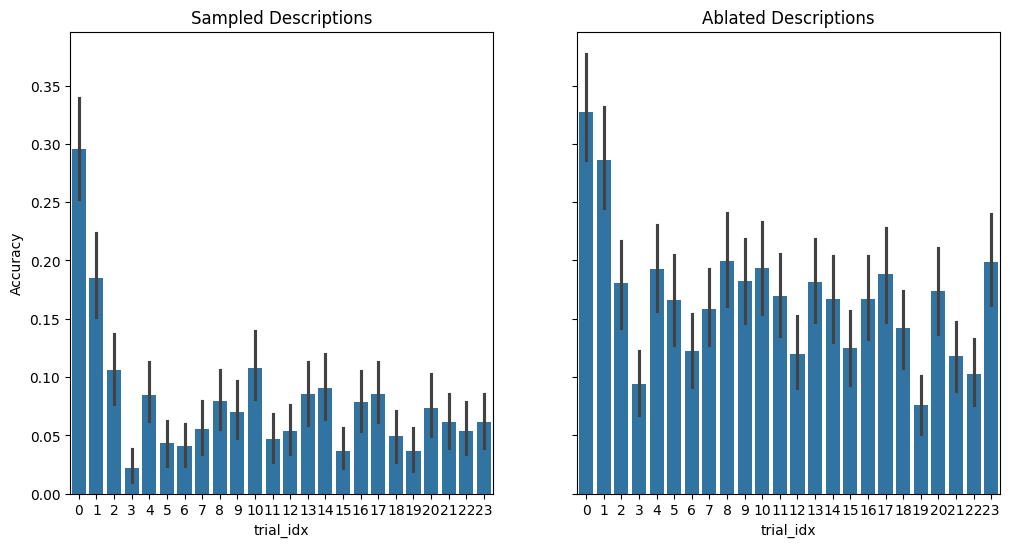

In [93]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=df[df.sampling_method == "top_p"], x="trial_idx", y="sampled_descriptions_correct", ax=ax1)
ax1.set_title("Sampled Descriptions")
ax1.set_ylabel("Accuracy")
sns.barplot(data=df[df.sampling_method == "top_p"], x="trial_idx", y="ablated_descriptions_correct", ax=ax2)
ax2.set_title("Ablated Descriptions")
ax2.set_ylabel("Accuracy")

Text(0, 0.5, 'Accuracy')

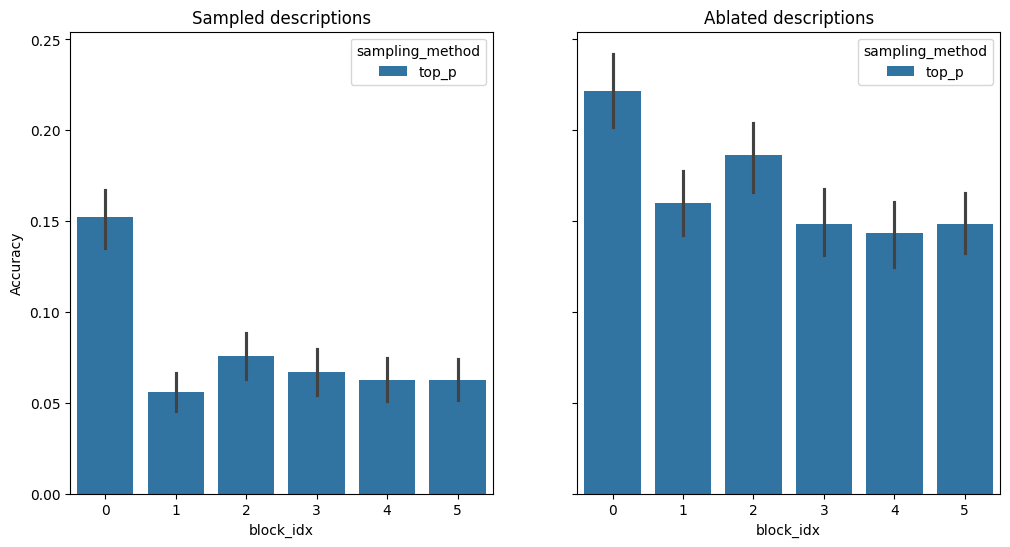

In [94]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=df[df.sampling_method == "top_p"], x="block_idx", y="sampled_descriptions_correct", hue="sampling_method", ax=ax1)
ax1.set_title("Sampled descriptions")
ax1.set_ylabel("Accuracy")
sns.barplot(data=df[df.sampling_method == "top_p"], x="block_idx", y="ablated_descriptions_correct", hue="sampling_method", ax=ax2)
ax2.set_title("Ablated descriptions")
ax2.set_ylabel("Accuracy")

Text(0, 0.5, 'Accuracy')

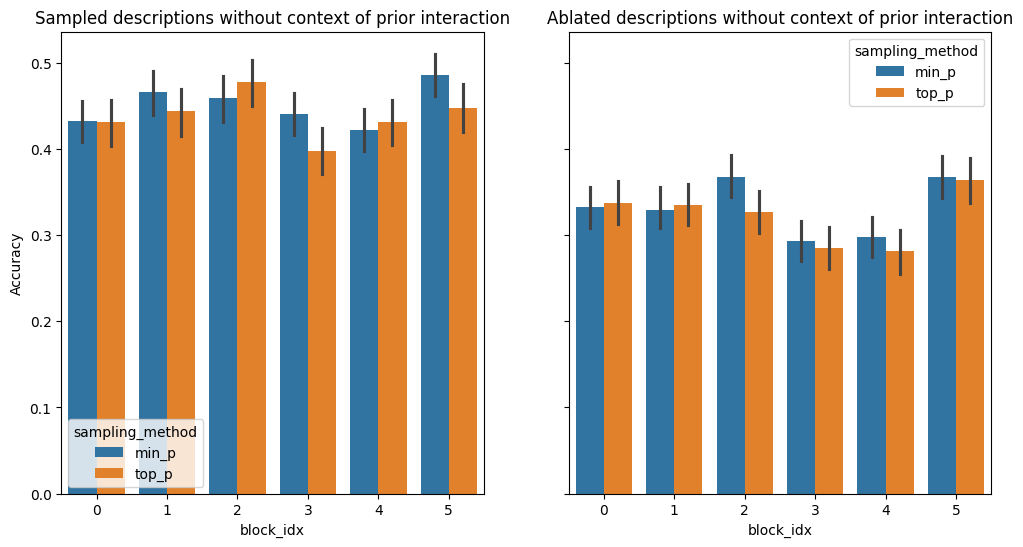

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=df, x="block_idx", y="sampled_descriptions_no_context_correct", hue="sampling_method", ax=ax1)
ax1.set_title("Sampled descriptions without context of prior interaction")
ax1.set_ylabel("Accuracy")
sns.barplot(data=df, x="block_idx", y="ablated_descriptions_no_context_correct", hue="sampling_method", ax=ax2)
ax2.set_title("Ablated descriptions without context of prior interaction")
ax2.set_ylabel("Accuracy")

Text(0, 0.5, '#words')

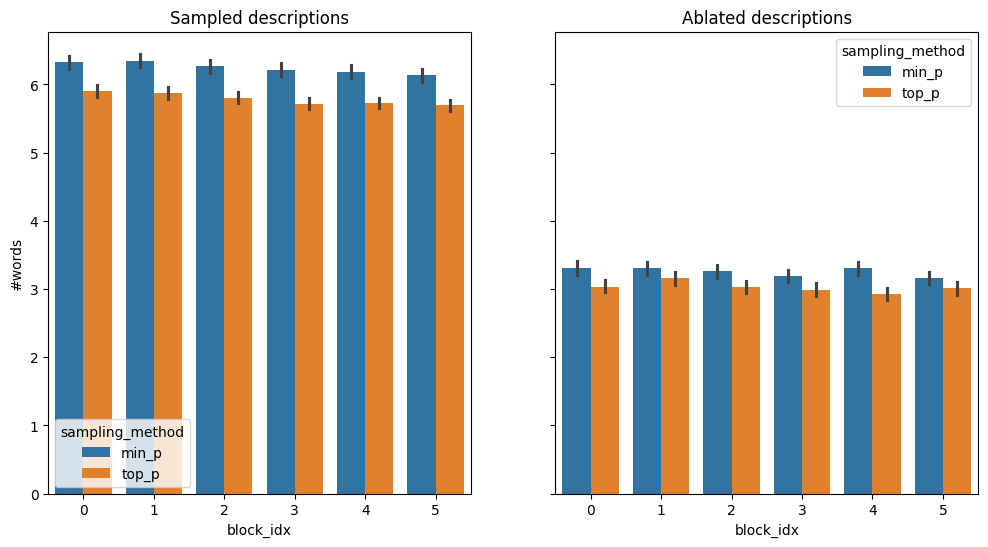

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=df, x="block_idx", y="sampled_descriptions_len", hue="sampling_method", ax=ax1)
ax1.set_title("Sampled descriptions")
ax1.set_ylabel("#words")
sns.barplot(data=df, x="block_idx", y="ablated_descriptions_len", hue="sampling_method", ax=ax2)
ax2.set_title("Ablated descriptions")
ax2.set_ylabel("#words")

<Axes: xlabel='block_idx', ylabel='tiled_description_correct'>

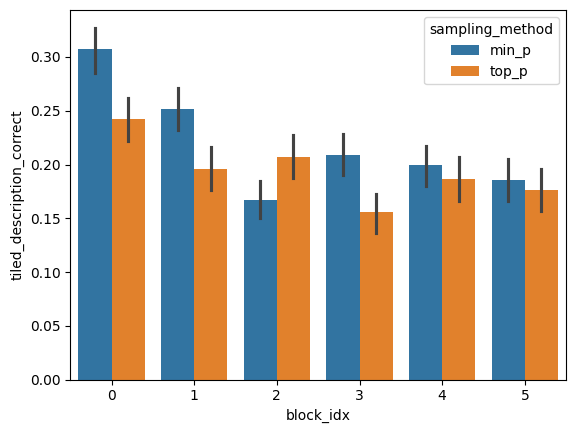

In [46]:
sns.barplot(data=df, x="block_idx", y="tiled_description_correct", hue="sampling_method")

<Axes: xlabel='trial_idx', ylabel='tiled_description_correct'>

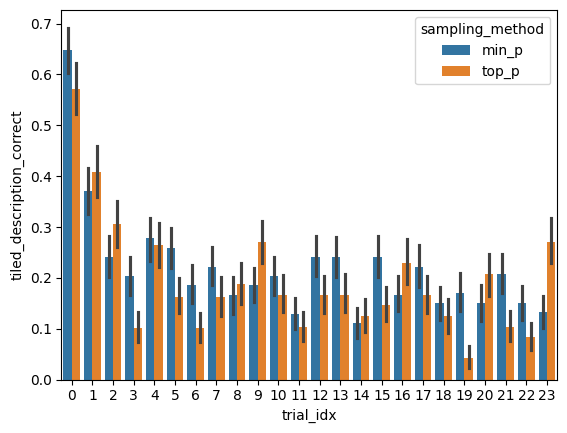

In [47]:
sns.barplot(data=df, x="trial_idx", y="tiled_description_correct", hue="sampling_method")

In [95]:
mean_agg_df = df.groupby(
    [
        "speaker_model",
        "speaker_sampling_method",
        "gameid",
        "trial_idx",
        "target",
        "block_idx",
    ]
).agg(
    {
        "sampled_descriptions_correct": "mean",
        "sampled_descriptions_no_context_correct": "mean",
        "ablated_descriptions_correct": "mean",
        "ablated_descriptions_no_context_correct": "mean",
        "tiled_description_correct": "mean",
    }
).reset_index()

Text(0, 0.5, 'Accuracy')

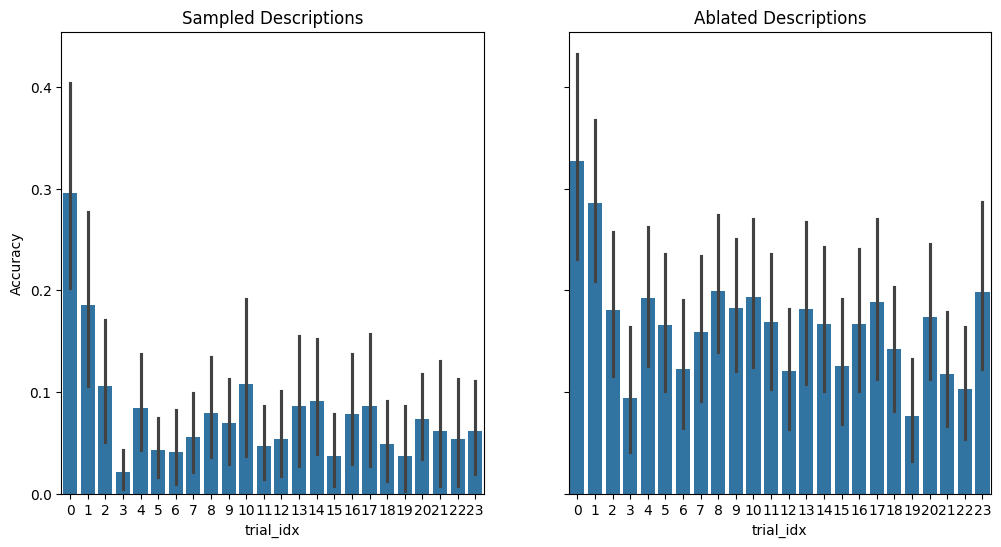

In [96]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=mean_agg_df[mean_agg_df.speaker_sampling_method == "top_p"], x="trial_idx", y="sampled_descriptions_correct", ax=ax1)
ax1.set_title("Sampled Descriptions")
ax1.set_ylabel("Accuracy")
sns.barplot(data=mean_agg_df[mean_agg_df.speaker_sampling_method == "top_p"], x="trial_idx", y="ablated_descriptions_correct", ax=ax2)
ax2.set_title("Ablated Descriptions")
ax2.set_ylabel("Accuracy")

In [97]:
max_agg_df = df.groupby(
    [
        "speaker_model",
        "speaker_sampling_method",
        "gameid",
        "trial_idx",
        "target",
        "block_idx"
    ]
).agg(
    {
        "sampled_descriptions_correct": "max",
        "sampled_descriptions_no_context_correct": "max",
        "ablated_descriptions_correct": "max",
        "ablated_descriptions_no_context_correct": "max",
        "tiled_description_correct": "max",
    }
).reset_index()

Text(0, 0.5, 'Accuracy')

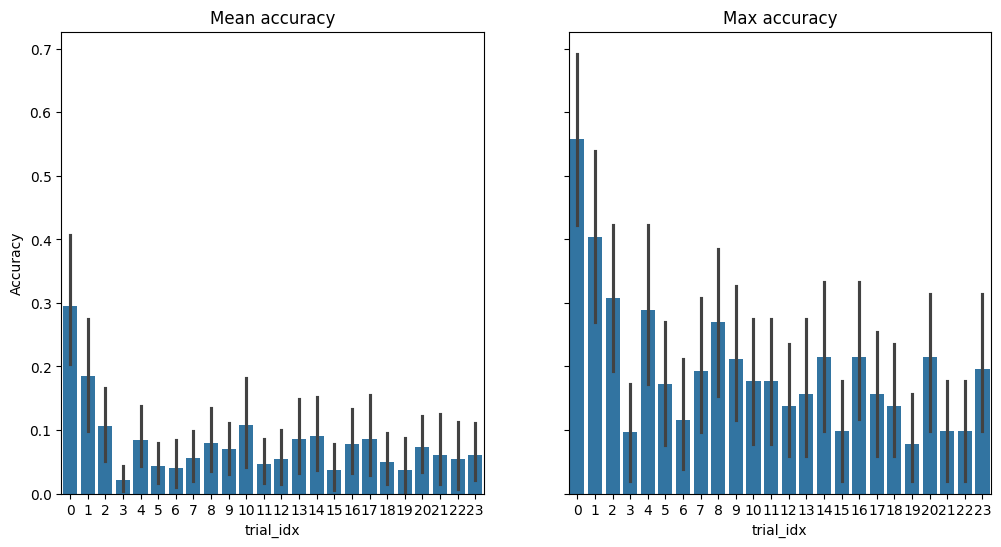

In [98]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=mean_agg_df[mean_agg_df.speaker_sampling_method == "top_p"], x="trial_idx", y="sampled_descriptions_correct", ax=ax1)
ax1.set_title("Mean accuracy")
ax1.set_ylabel("Accuracy")
sns.barplot(data=max_agg_df[max_agg_df.speaker_sampling_method == "top_p"], x="trial_idx", y="sampled_descriptions_correct", ax=ax2)
ax2.set_title("Max accuracy")
ax2.set_ylabel("Accuracy")

Text(0, 0.5, 'Accuracy')

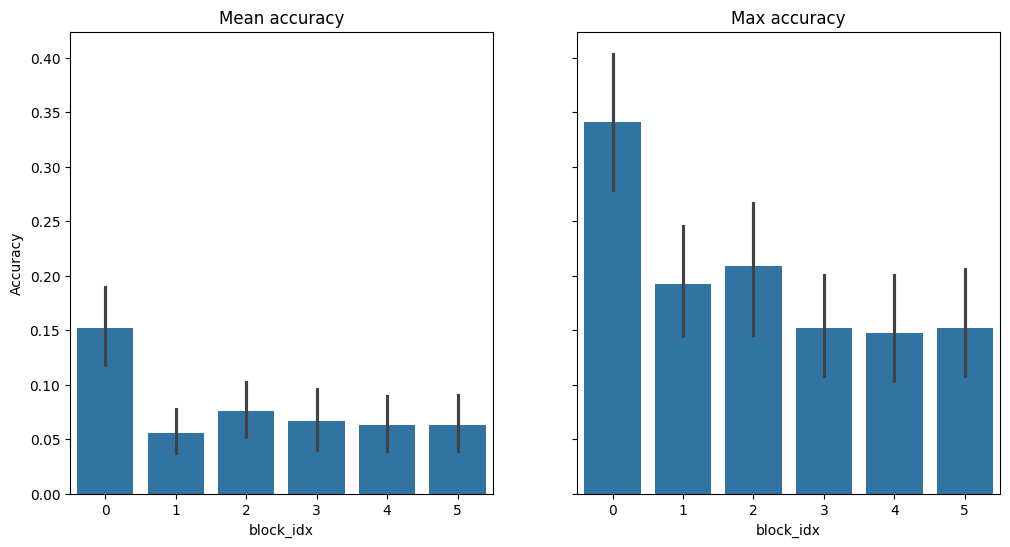

In [99]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=mean_agg_df[mean_agg_df.speaker_sampling_method == "top_p"], x="block_idx", y="sampled_descriptions_correct", ax=ax1)
ax1.set_title("Mean accuracy")
ax1.set_ylabel("Accuracy")
sns.barplot(data=max_agg_df[max_agg_df.speaker_sampling_method == "top_p"], x="block_idx", y="sampled_descriptions_correct", ax=ax2)
ax2.set_title("Max accuracy")
ax2.set_ylabel("Accuracy")

Text(0, 0.5, 'Accuracy')

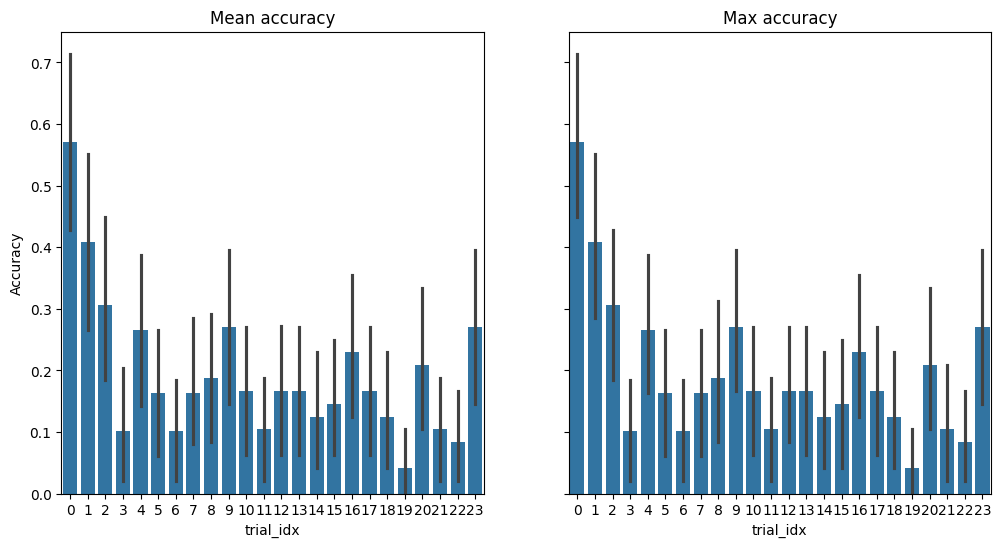

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=mean_agg_df[mean_agg_df.speaker_sampling_method == "top_p"], x="trial_idx", y="tiled_description_correct", ax=ax1)
ax1.set_title("Mean accuracy")
ax1.set_ylabel("Accuracy")
sns.barplot(data=max_agg_df[max_agg_df.speaker_sampling_method == "top_p"], x="trial_idx", y="tiled_description_correct", ax=ax2)
ax2.set_title("Max accuracy")
ax2.set_ylabel("Accuracy")

In [69]:
df.gameid.unique()

array(['0316-f782f20f-6b40-4846-b1f7-e5e8447b87c9',
       '0518-1801bcc1-4d64-464c-99f3-6e4bc34d2b9a',
       '0525-6aa6a04d-370d-4465-8024-fb0fb373fac0',
       '0727-2931b6d4-585e-4d15-9737-764bc0cb77f3',
       '0788-0101405f-5745-4c8c-a882-d4eaf34b45fd',
       '1006-8a964204-bce4-48de-9bb1-2933a4c017f7',
       '1462-0f5defdf-dbd8-48d7-abdc-f4be3269ba28',
       '1733-362e3f99-ce8f-43b1-bc27-4c45de91aa40',
       '1769-4c90f5bb-b1da-4a22-a052-c282724b78e8',
       '1970-9004306c-6812-4765-b5b3-c71fe2958c9f',
       '2081-8e379b3a-c6df-4b3c-a596-87870350b8d5',
       '2088-b4bb52a2-3cd8-4303-85bf-ca3a90c6fd69',
       '2421-6e995a34-20c9-4f55-be01-99f6707e0b72',
       '2552-40d189c7-231f-4831-b884-3d0090e5d256',
       '2575-894b8bf3-1a9e-40c8-acd2-9b3b73641f4a',
       '2635-51f6aa15-c301-4b51-b134-c229603e1be5',
       '2740-3a3091eb-b0ca-4ba2-8a33-8badb85efc06',
       '4425-e80ade8f-82e5-40b4-9644-c9993e2ff689',
       '4831-98a48100-302d-41ce-ac49-08a3c2e88ea4',
       '4849

In [100]:
df[
    (df.gameid == "0788-0101405f-5745-4c8c-a882-d4eaf34b45fd")
    & (df.speaker_sampling_method == "top_p")
].groupby(
    [
        "speaker_model",
        "speaker_sampling_method",
        "selected_description",
        "gameid",
        "trial_idx",
        "target",
        "block_idx",
    ]
).agg(
    {
        "sampled_descriptions_correct": "mean",
        "ablated_descriptions_correct": "mean",
        "tiled_description_correct": "mean",
    }
).reset_index().sort_values(by='trial_idx')

,speaker_model,speaker_sampling_method,selected_description,gameid,trial_idx,target,block_idx,sampled_descriptions_correct,ablated_descriptions_correct,tiled_description_correct
7,mistral-community/pixtral-12b,top_p,Person kiteboarding in the ocean.,0788-0101405f-5745-4c8c-a882-d4eaf34b45fd,0,COCO_val2014_000000408534.jpg,0,0.000,0.000,0.0
4,mistral-community/pixtral-12b,top_p,Person in the air with a kite.,0788-0101405f-5745-4c8c-a882-d4eaf34b45fd,1,COCO_val2014_000000317070.jpg,0,0.000,0.125,0.0
20,mistral-community/pixtral-12b,top_p,"Person windsurfing, flying in the air.",0788-0101405f-5745-4c8c-a882-d4eaf34b45fd,2,COCO_val2014_000000272958.jpg,0,0.000,0.000,0.0
22,mistral-community/pixtral-12b,top_p,Surfer jumping over wave.,0788-0101405f-5745-4c8c-a882-d4eaf34b45fd,3,COCO_val2014_000000339676.jpg,0,0.000,0.000,0.0
15,mistral-community/pixtral-12b,top_p,"Person on a board, flying a kite.",0788-0101405f-5745-4c8c-a882-d4eaf34b45fd,4,COCO_val2014_000000408534.jpg,1,0.125,0.375,1.0
14,mistral-community/pixtral-12b,top_p,"Person on a board, being pulled by a kite.",0788-0101405f-5745-4c8c-a882-d4eaf34b45fd,5,COCO_val2014_000000272958.jpg,1,0.000,0.000,0.0
21,mistral-community/pixtral-12b,top_p,Surfer in the air above the wave.,0788-0101405f-5745-4c8c-a882-d4eaf34b45fd,6,COCO_val2014_000000339676.jpg,1,0.000,0.000,0.0
0,mistral-community/pixtral-12b,top_p,Person flying high with a kite.,0788-0101405f-5745-4c8c-a882-d4eaf34b45fd,7,COCO_val2014_000000317070.jpg,1,0.000,0.000,0.0
12,mistral-community/pixtral-12b,top_p,Person kiteboarding over water.,0788-0101405f-5745-4c8c-a882-d4eaf34b45fd,8,COCO_val2014_000000272958.jpg,2,0.125,0.750,1.0
23,mistral-community/pixtral-12b,top_p,Surfer riding high above water.,0788-0101405f-5745-4c8c-a882-d4eaf34b45fd,9,COCO_val2014_000000339676.jpg,2,0.000,0.250,0.0
